<a href="https://colab.research.google.com/github/cdhaskett/TaxiColor/blob/main/GB885_Assignment_4_Haskett_C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We want to find out if there is a diference in the average tip in a yellow cab versus a green cab. We have ride data information and want to peform a 2 sample t-test.

In [ ]:
#First we will need to import all libraries needed
import pandas as pd
import numpy as np
import scipy.stats as stats

Now we need to load our data into a dataframe. I am going to use pandas to do so.

In [ ]:
df_taxi_samples = pd.read_csv('https://bit.ly/taxi-samples')

In [ ]:
#Now that we have our dataframe--it's always good practice to expore the data and what columns you have.
df_taxi_samples.head()

,id,passengers,color,distance,fare,tip,tolls,total
0,1,1,green,0.72,5.5,1.11,0.0,7.56
1,2,3,yellow,2.16,10.0,2.88,0.0,15.80
2,3,1,green,0.15,7.0,2.19,0.0,8.40
3,4,3,yellow,7.35,22.5,5.38,0.0,27.30
4,5,1,green,3.44,12.5,3.35,0.0,15.96


In [ ]:
#Now that we have the columns --let's check out the descriptive stats.
df_taxi_samples.describe()

,id,passengers,distance,fare,tip,tolls,total
count,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000
mean,292.500000,1.446918,2.333699,10.687500,2.651558,0.053836,15.912483
std,168.730554,1.126900,2.038913,6.368975,1.364825,0.541843,7.891350
min,1.000000,0.000000,0.000000,3.000000,0.060000,0.000000,4.810000
25%,146.750000,1.000000,1.000000,6.500000,1.697500,0.000000,10.380000
50%,292.500000,1.000000,1.595000,8.500000,2.580000,0.000000,13.555000
75%,438.250000,1.000000,3.012500,13.125000,3.530000,0.000000,19.560000
max,584.000000,6.000000,13.900000,50.000000,7.730000,5.760000,57.800000


In [ ]:
#Let's look at the shape of the dataframe.
df_taxi_samples.shape

#Then let's check out the type of data.
df_taxi_samples.dtypes

,0
id,int64
passengers,int64
color,object
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64


Now we want to split the yellow cab and green cab data into two seperate dataframes.

In [ ]:
df_yellow_cab = df_taxi_samples[df_taxi_samples['color'] == 'yellow']
df_green_cab = df_taxi_samples[df_taxi_samples['color'] == 'green']


In [ ]:
#Let's test the yellow:
df_yellow_cab.head()

,id,passengers,color,distance,fare,tip,tolls,total
1,2,3,yellow,2.16,10.0,2.88,0.0,15.8
3,4,3,yellow,7.35,22.5,5.38,0.0,27.3
5,6,1,yellow,7.00,25.5,7.57,0.0,36.6
7,8,4,yellow,0.74,4.5,0.26,0.0,9.3
9,10,1,yellow,5.34,19.0,4.48,0.0,24.8


In [ ]:
#Let's test the green:
df_green_cab.head()

,id,passengers,color,distance,fare,tip,tolls,total
0,1,1,green,0.72,5.5,1.11,0.0,7.56
2,3,1,green,0.15,7.0,2.19,0.0,8.40
4,5,1,green,3.44,12.5,3.35,0.0,15.96
6,7,1,green,1.77,14.0,3.45,0.0,19.75
8,9,1,green,8.26,26.0,5.39,0.0,36.66


Since we know that the dataframes are listing the correct colors and columns we can continue on to making a histogram with the tip distribution data.


In [ ]:
#We need to upload the seaborn library.
import seaborn as sns

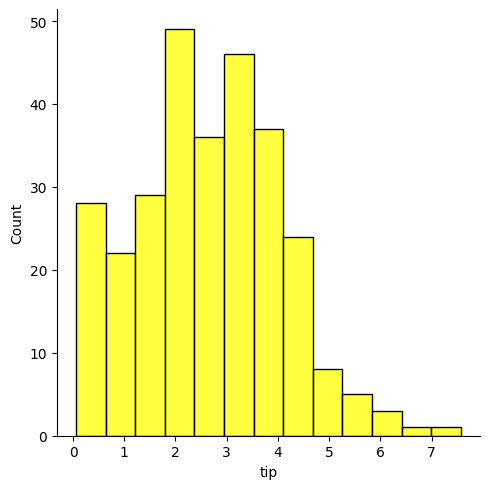

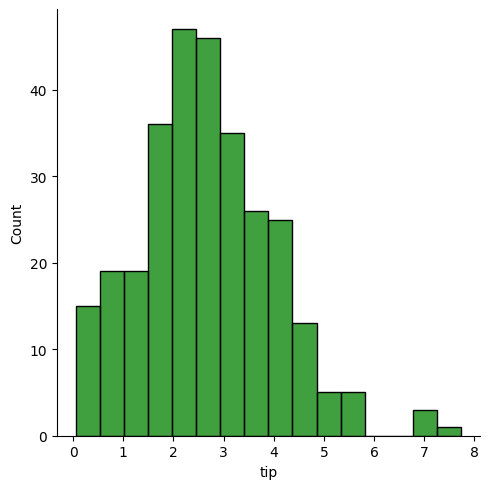

In [ ]:
#Let's create our historgrams to see the distriubtion of tips.

sns.displot(df_yellow_cab['tip'], color='yellow')
sns.displot(df_green_cab['tip'], color='green')

Now we are going to shift gears (see what I did there) and look at normality and t-tests.

In [ ]:
#Since we have already created our seperate tables, we will easily assing variables to these.
x = df_yellow_cab ['tip']
y = df_green_cab  ['tip']

In [ ]:
#Let's conduct a normality test:
print(stats.normaltest(x))
print(stats.normaltest(y))

NormaltestResult(statistic=np.float64(3.64258187700985), pvalue=np.float64(0.16181672060489052))
NormaltestResult(statistic=np.float64(18.463276952811235), pvalue=np.float64(9.789270985641703e-05))


Yellow cab's p value is greater than .05, meaning it's normal enough, while the green cab's p value is not normal because it's less than .05.

In [ ]:
#Prior to moving on to a 2-sample t-test, we need to perform at a Bartlett's test to evaluate the equal variance of the two datasets.
stats.bartlett(x,y)


BartlettResult(statistic=np.float64(0.7714482981698573), pvalue=np.float64(0.37976938229166823))

Now we are going to create a 2-sample t-test to determine if there is a statistically significant difference in tips bewteen yellow and green taxi cab.

In [ ]:
#We will conduct a t-test:
ttest_results = stats.ttest_ind(x,y)
print(ttest_results)

#Since our result is greater than .050 we are "failing to reject the null"


TtestResult(statistic=np.float64(0.04542243544132782), pvalue=np.float64(0.9637861790300399), df=np.float64(582.0))
